# Diabetes — Estadística Inferencial

### Objetivo

Identificar y cuantificar qué factores explican la progresión de la diabetes (variable `Y`), aplicando las herramientas de estadística inferencial vistas en clase sobre el dataset limpio preparado en sesiones anteriores.

El análisis combina distribución normal y tipificación, probabilidad condicional con Bayes, distribución binomial, y pruebas de hipótesis con T-Test y ANOVA. Cada técnica se acompaña de la verificación de sus supuestos y del tamaño del efecto, para distinguir cuándo una diferencia es real y cuándo es relevante.


### Carga de datos

Se cargan dos versiones. El dataset limpio, con el que se trabaja, y el crudo, que se usa solo al final para una comparación visual. El limpio tiene 9 columnas en lugar de 11, ya que se eliminaron `S2` por su redundancia con `S1` y `S4` por ser el cociente derivado entre `S1` y `S3`.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

df = pd.read_csv("../data/processed/diabetes_limpio.csv")
df_sin_limpiar = pd.read_csv("../data/raw/diabetes.tab.txt", sep="\t")

print(f"Limpio:      {df.shape}")
print(f"Sin limpiar: {df_sin_limpiar.shape}")
df.head()

Limpio:      (442, 9)
Sin limpiar: (442, 11)


,AGE,SEX,BMI,BP,S1,S3,S5,S6,Y
0,59,2,32.1,101.0,157,38.0,4.8598,87,151
1,48,1,21.6,87.0,183,70.0,3.8918,69,75
2,72,2,30.5,93.0,156,41.0,4.6728,85,141
3,24,1,25.3,84.0,198,40.0,4.8903,89,206
4,50,1,23.0,101.0,192,52.0,4.2905,80,135


## 1. Estadística descriptiva

Resumen de posición, dispersión y forma para todas las variables numéricas. Sirve como punto de partida antes de cualquier inferencia.


In [2]:
num_vars = ["AGE", "BMI", "BP", "S1", "S3", "S5", "S6", "Y"]

resumen = pd.DataFrame(
    {
        "Media": df[num_vars].mean(),
        "Mediana": df[num_vars].median(),
        "Desv. Est.": df[num_vars].std(),
        "Asimetría": df[num_vars].skew(),
        "Curtosis": df[num_vars].apply(lambda x: stats.kurtosis(x)),
    }
).round(2)
resumen


,Media,Mediana,Desv. Est.,Asimetría,Curtosis
AGE,48.52,50.00,13.11,-0.23,-0.68
BMI,26.38,25.70,4.42,0.60,0.08
BP,94.65,93.00,13.83,0.29,-0.54
S1,189.14,186.00,34.61,0.38,0.22
S3,49.79,48.00,12.93,0.80,0.96
S5,4.64,4.62,0.52,0.29,-0.15
S6,91.26,91.00,11.50,0.21,0.22
Y,152.13,140.50,77.09,0.44,-0.89


La asimetría positiva de `Y` confirma su cola hacia la derecha. Estos valores de forma anticipan que la normalidad podría no cumplirse, algo que se verifica a continuación.


## 2. Distribución normal

La clase trabajó la distribución normal, la tipificación con la variable Z y la regla 68-95-99.7. Como el T-Test y el ANOVA asumen normalidad, conviene comprobar si las variables la cumplen antes de aplicarlos.


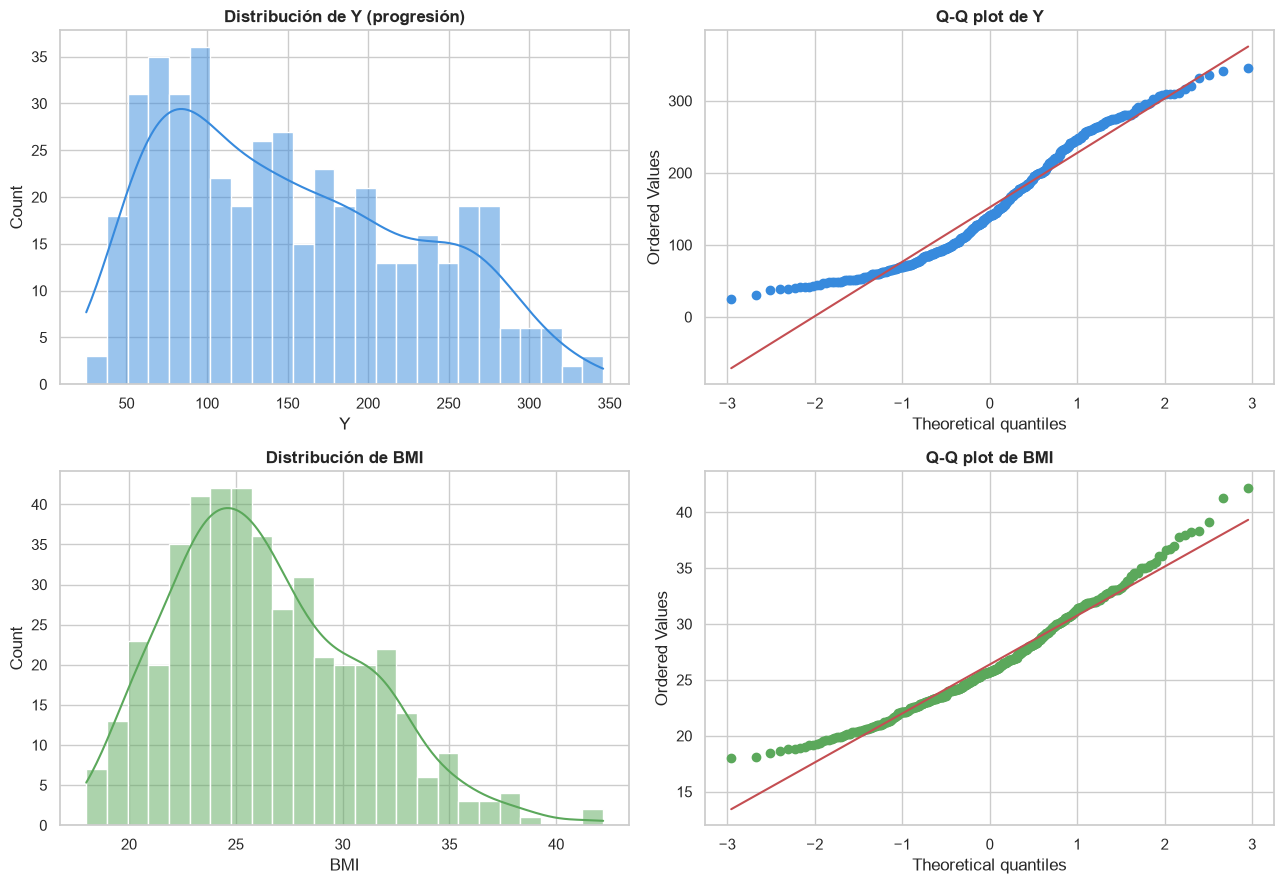

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df["Y"], kde=True, color="#378ADD", bins=25, ax=axes[0, 0])
axes[0, 0].set_title("Distribución de Y (progresión)", fontweight="bold")

stats.probplot(df["Y"], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q plot de Y", fontweight="bold")
axes[0, 1].get_lines()[0].set_markerfacecolor("#378ADD")
axes[0, 1].get_lines()[0].set_markeredgecolor("#378ADD")

sns.histplot(df["BMI"], kde=True, color="#5BA85B", bins=25, ax=axes[1, 0])
axes[1, 0].set_title("Distribución de BMI", fontweight="bold")

stats.probplot(df["BMI"], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot de BMI", fontweight="bold")
axes[1, 1].get_lines()[0].set_markerfacecolor("#5BA85B")
axes[1, 1].get_lines()[0].set_markeredgecolor("#5BA85B")

plt.tight_layout()
plt.show()


In [4]:
print("Prueba de normalidad de Shapiro-Wilk")
print(f"{'Variable':<8}{'W':>10}{'p-valor':>12}   Conclusión")
print("-" * 48)
for v in num_vars:
    W, p = stats.shapiro(df[v])
    print(f"{v:<8}{W:>10.4f}{p:>12.5f}   {'normal' if p > 0.05 else 'NO normal'}")


Prueba de normalidad de Shapiro-Wilk
Variable         W     p-valor   Conclusión
------------------------------------------------
AGE         0.9824     0.00003   NO normal
BMI         0.9728     0.00000   NO normal
BP          0.9837     0.00007   NO normal
S1          0.9903     0.00513   NO normal
S3          0.9632     0.00000   NO normal
S5          0.9911     0.00956   NO normal
S6          0.9931     0.04095   NO normal
Y           0.9491     0.00000   NO normal


Ninguna variable pasa la prueba, todos los p-valores son menores a 0.05. El Q-Q plot de `Y` lo confirma visualmente, los puntos se separan de la diagonal en los extremos. Por eso, las pruebas que siguen se acompañan de sus versiones no paramétricas, que no dependen de la normalidad.


### Tipificación y regla 68-95-99.7

La tipificación lleva una variable a la escala Z mediante Z igual a X menos la media sobre la desviación. Sobre esa escala, la regla empírica predice que el 68%, el 95% y el 99.7% de los datos caen dentro de una, dos y tres desviaciones. Se contrasta con lo que ocurre en los datos reales.


In [5]:
def regla_empirica(serie, nombre):
    m, s = serie.mean(), serie.std()
    print(f"{nombre} (media={m:.1f}, desv={s:.1f})")
    for k, teorico in [(1, 68.0), (2, 95.0), (3, 99.7)]:
        pct = ((serie >= m - k * s) & (serie <= m + k * s)).mean() * 100
        print(f"   ±{k}σ:  empírico {pct:5.1f}%   vs teórico {teorico:5.1f}%")
    print()


regla_empirica(df["BMI"], "BMI")
regla_empirica(df["Y"], "Y")


BMI (media=26.4, desv=4.4)
   ±1σ:  empírico  67.6%   vs teórico  68.0%
   ±2σ:  empírico  96.6%   vs teórico  95.0%
   ±3σ:  empírico  99.5%   vs teórico  99.7%

Y (media=152.1, desv=77.1)
   ±1σ:  empírico  59.5%   vs teórico  68.0%
   ±2σ:  empírico  97.5%   vs teórico  95.0%
   ±3σ:  empírico 100.0%   vs teórico  99.7%



`BMI` se ajusta casi perfecto a la regla, lo que indica un comportamiento cercano a la normal. `Y` se aparta en la primera banda, con un 59.5% frente al 68% esperado, coherente con su asimetría.


### Estimación por intervalo de la media de `Y`

Una herramienta central de la inferencia es estimar un parámetro poblacional con un margen de error. Se calcula el intervalo de confianza al 95% para la media de progresión usando la distribución t, apropiada porque se desconoce la varianza poblacional.


In [6]:
media = df["Y"].mean()
sem = stats.sem(df["Y"])
ic = stats.t.interval(0.95, len(df["Y"]) - 1, loc=media, scale=sem)

print(f"Media muestral de Y: {media:.2f}")
print(f"Intervalo de confianza 95%: [{ic[0]:.2f}, {ic[1]:.2f}]")
print(f"Margen de error: ±{(ic[1] - ic[0]) / 2:.2f}")


Media muestral de Y: 152.13
Intervalo de confianza 95%: [144.93, 159.34]
Margen de error: ±7.21


Con un 95% de confianza, la media poblacional de progresión está entre 145 y 159 aproximadamente. El margen de error es estrecho gracias al tamaño de muestra de 442 pacientes.


### Probabilidad con el modelo normal

Aprovechando la tipificación, se estima qué probabilidad habría de hallar un paciente con `Y` mayor a 200 bajo un modelo normal, y se contrasta con la proporción observada.


Z para Y=200: 0.621
P(Y > 200) modelo normal: 26.7%
P(Y > 200) observado:     27.4%


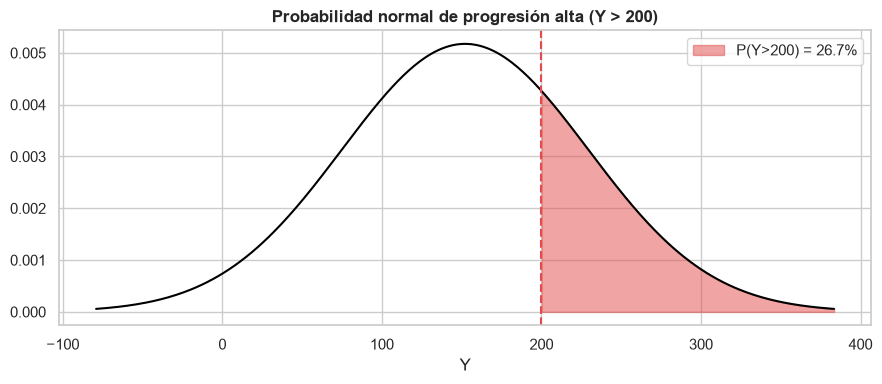

In [7]:
m, s = df["Y"].mean(), df["Y"].std()
x = 200
z = (x - m) / s
p_teorico = 1 - stats.norm.cdf(z)
p_empirico = (df["Y"] > x).mean()

print(f"Z para Y=200: {z:.3f}")
print(f"P(Y > 200) modelo normal: {p_teorico * 100:.1f}%")
print(f"P(Y > 200) observado:     {p_empirico * 100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 4))
xs = np.linspace(m - 3 * s, m + 3 * s, 400)
ax.plot(xs, stats.norm.pdf(xs, m, s), color="black")
xfill = xs[xs >= x]
ax.fill_between(
    xfill,
    stats.norm.pdf(xfill, m, s),
    color="#E24B4A",
    alpha=0.5,
    label=f"P(Y>200) = {p_teorico * 100:.1f}%",
)
ax.axvline(x, color="#E24B4A", linestyle="--")
ax.set_title("Probabilidad normal de progresión alta (Y > 200)", fontweight="bold")
ax.set_xlabel("Y")
ax.legend()
plt.tight_layout()
plt.show()


El modelo estima 26.7% y los datos muestran 27.4%. La aproximación es buena pese a que `Y` no es estrictamente normal, lo que muestra la utilidad práctica del modelo aun con un ajuste imperfecto.


## 3. Probabilidad condicional y Bayes

La clase trabajó la probabilidad condicional y el teorema de Bayes. Se aplica el mismo razonamiento a la pregunta de fondo, ¿saber que un paciente tiene BMI alto cambia la probabilidad de que su diabetes progrese rápido? Se construye una tabla de contingencia clasificando cada paciente según si su BMI y su `Y` superan la mediana.


In [8]:
df["BMI_alto"] = df["BMI"] > df["BMI"].median()
df["Y_alto"] = df["Y"] > df["Y"].median()

tabla = pd.crosstab(df["BMI_alto"], df["Y_alto"], rownames=["BMI alto"], colnames=["Y alto"])
print(tabla)

p_y = df["Y_alto"].mean()
p_y_dado_bmi = df[df["BMI_alto"]]["Y_alto"].mean()
p_y_dado_no_bmi = df[~df["BMI_alto"]]["Y_alto"].mean()

print(f"\nP(Y alto)              = {p_y:.3f}")
print(f"P(Y alto | BMI alto)   = {p_y_dado_bmi:.3f}")
print(f"P(Y alto | BMI bajo)   = {p_y_dado_no_bmi:.3f}")


Y alto    False  True 
BMI alto              
False       157     66
True         64    155

P(Y alto)              = 0.500
P(Y alto | BMI alto)   = 0.708
P(Y alto | BMI bajo)   = 0.296


La probabilidad base de progresión alta es del 50%. Al condicionar sobre BMI alto sube al 70.8%, y sobre BMI bajo baja al 29.6%. Conocer el BMI modifica de forma importante la expectativa de progresión.


In [9]:
# Bayes invierte la condición
p_bmi = df["BMI_alto"].mean()
p_bmi_dado_y = (p_y_dado_bmi * p_bmi) / p_y
print(f"Por Bayes, P(BMI alto | Y alto) = {p_bmi_dado_y:.3f}")
print(f"Verificación directa            = {df[df['Y_alto']]['BMI_alto'].mean():.3f}")

chi2, p_chi, gl, _ = stats.chi2_contingency(tabla)
print(f"\nChi-cuadrado de independencia: chi2 = {chi2:.2f}, p = {p_chi:.2e}")
print("Conclusión:", "hay asociación significativa" if p_chi < 0.05 else "sin asociación")


Por Bayes, P(BMI alto | Y alto) = 0.701
Verificación directa            = 0.701

Chi-cuadrado de independencia: chi2 = 73.31, p = 1.11e-17
Conclusión: hay asociación significativa


Bayes da el mismo valor por dos caminos, lo que confirma la consistencia. El chi-cuadrado, con un p-valor del orden de diez a la menos diecisiete, rechaza la independencia. BMI y progresión están asociados, no por azar.


## 4. Distribución binomial

La binomial modela el número de éxitos en n ensayos independientes con probabilidad constante. Aquí responde, si se eligen al azar n pacientes, ¿cuántos tendrán progresión alta? Se define éxito como `Y` por encima de la mediana, con probabilidad cercana a 0.5.


p = 0.500  en muestra de n = 10
   P(exactamente 6 altos) = 0.2051
   P(al menos 8 altos)    = 0.0547


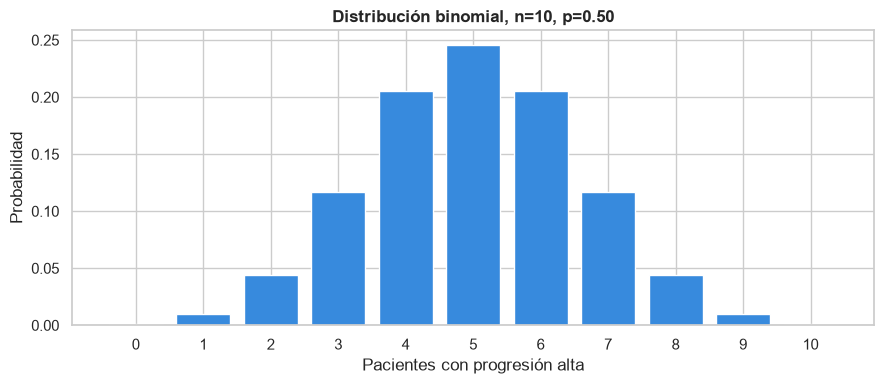

In [10]:
p_exito = (df["Y"] > df["Y"].median()).mean()
n = 10

print(f"p = {p_exito:.3f}  en muestra de n = {n}")
print(f"   P(exactamente 6 altos) = {stats.binom.pmf(6, n, p_exito):.4f}")
print(f"   P(al menos 8 altos)    = {1 - stats.binom.cdf(7, n, p_exito):.4f}")

k = np.arange(0, n + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(k, stats.binom.pmf(k, n, p_exito), color="#378ADD", edgecolor="white")
ax.set_title(f"Distribución binomial, n={n}, p={p_exito:.2f}", fontweight="bold")
ax.set_xlabel("Pacientes con progresión alta")
ax.set_ylabel("Probabilidad")
ax.set_xticks(k)
plt.tight_layout()
plt.show()


La distribución es simétrica alrededor de 5. Hallar exactamente 6 pacientes con progresión alta en 10 tiene un 20.5% de probabilidad, mientras que hallar 8 o más es raro, apenas 5.5%.


## 5. T-Test, progresión por sexo

Se compara la progresión entre sexos con el T-Test, y se añade la verificación de igualdad de varianzas, una prueba no paramétrica de respaldo y el tamaño del efecto. El p-valor indica si hay diferencia, el tamaño del efecto indica si esa diferencia importa.


In [11]:
sexo_1 = df[df["SEX"] == 1]["Y"]
sexo_2 = df[df["SEX"] == 2]["Y"]

t_stat, p_t = stats.ttest_ind(sexo_1, sexo_2)
lev_stat, p_lev = stats.levene(sexo_1, sexo_2)
u_stat, p_u = stats.mannwhitneyu(sexo_1, sexo_2)

nx, ny = len(sexo_1), len(sexo_2)
sp = np.sqrt(((nx - 1) * sexo_1.var() + (ny - 1) * sexo_2.var()) / (nx + ny - 2))
d_cohen = (sexo_1.mean() - sexo_2.mean()) / sp

print(f"Media sexo 1: {sexo_1.mean():.1f}   Media sexo 2: {sexo_2.mean():.1f}")
print(f"T-Test:        t = {t_stat:.4f}   p = {p_t:.4f}")
print(f"Levene:        p = {p_lev:.4f}  ({'varianzas iguales' if p_lev > 0.05 else 'distintas'})")
print(f"Mann-Whitney:  p = {p_u:.4f}")
print(f"d de Cohen:    {d_cohen:.3f}  (despreciable si |d|<0.2)")


Media sexo 1: 149.0   Media sexo 2: 155.7
T-Test:        t = -0.9041   p = 0.3664
Levene:        p = 0.4232  (varianzas iguales)
Mann-Whitney:  p = 0.4324
d de Cohen:    -0.086  (despreciable si |d|<0.2)


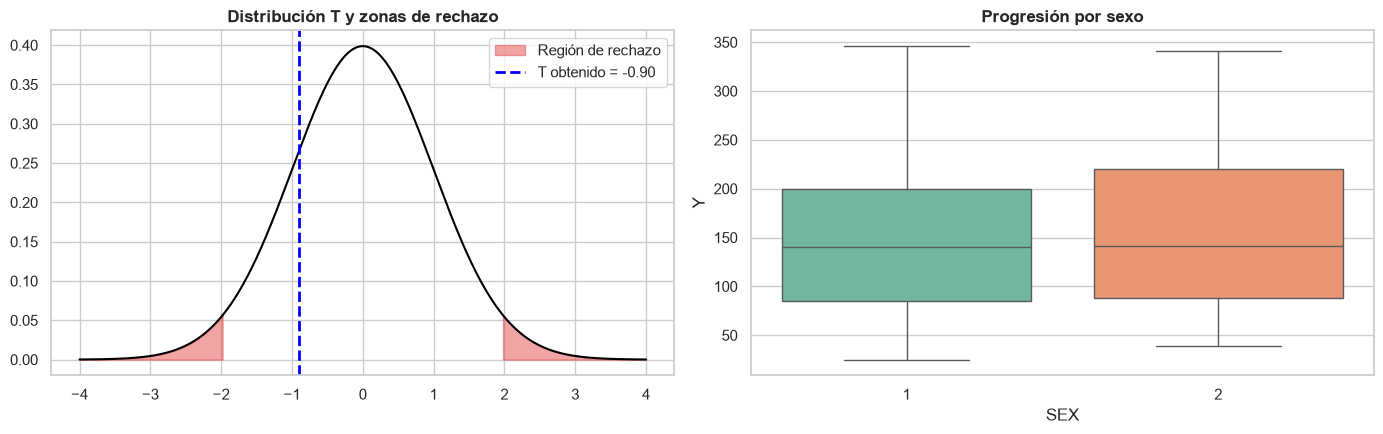

In [12]:
gl = nx + ny - 2
t_critico = stats.t.ppf(1 - 0.025, gl)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.linspace(-4, 4, 500)
ax1.plot(x, stats.t.pdf(x, gl), color="black")
ax1.fill_between(
    x[x <= -t_critico],
    stats.t.pdf(x[x <= -t_critico], gl),
    color="#E24B4A",
    alpha=0.5,
    label="Región de rechazo",
)
ax1.fill_between(x[x >= t_critico], stats.t.pdf(x[x >= t_critico], gl), color="#E24B4A", alpha=0.5)
ax1.axvline(t_stat, color="blue", linestyle="--", linewidth=2, label=f"T obtenido = {t_stat:.2f}")
ax1.set_title("Distribución T y zonas de rechazo", fontweight="bold")
ax1.legend()

sns.boxplot(x="SEX", y="Y", data=df, hue="SEX", palette="Set2", legend=False, ax=ax2)
ax2.set_title("Progresión por sexo", fontweight="bold")

plt.tight_layout()
plt.show()


Las tres pruebas coinciden. T-Test con p igual a 0.366, Mann-Whitney lo respalda con 0.432 y Levene confirma varianzas iguales. El d de Cohen de menos 0.086 muestra un efecto despreciable. El sexo no es un factor relevante para la progresión.


## 6. ANOVA, progresión por BMI

Se categoriza BMI en terciles y se comparan las medias de progresión con ANOVA, sumando la verificación de homogeneidad de varianzas, la alternativa de Kruskal-Wallis, el tamaño del efecto eta cuadrado y la prueba post-hoc de Tukey, que identifica entre qué grupos está la diferencia.


In [13]:
df["BMI_cat"] = pd.qcut(df["BMI"], q=3, labels=["BMI Bajo", "BMI Medio", "BMI Alto"])
grupos = [df[df["BMI_cat"] == c]["Y"] for c in ["BMI Bajo", "BMI Medio", "BMI Alto"]]

f_stat, p_anova = stats.f_oneway(*grupos)
lev_stat, p_lev = stats.levene(*grupos)
h_stat, p_kruskal = stats.kruskal(*grupos)

grand = df["Y"].mean()
ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in grupos)
ss_total = ((df["Y"] - grand) ** 2).sum()
eta2 = ss_between / ss_total

print(f"ANOVA:          F = {f_stat:.2f}   p = {p_anova:.2e}")
print(f"Levene:         p = {p_lev:.4f}  ({'iguales' if p_lev > 0.05 else 'distintas'})")
print(f"Kruskal-Wallis: p = {p_kruskal:.2e}")
print(f"eta cuadrado:   {eta2:.3f}  (efecto grande si >0.14)")


ANOVA:          F = 95.40   p = 3.95e-35
Levene:         p = 0.0000  (distintas)
Kruskal-Wallis: p = 1.42e-28
eta cuadrado:   0.303  (efecto grande si >0.14)


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1    group2   meandiff p-adj   lower    upper   reject
------------------------------------------------------------
BMI Alto  BMI Bajo -101.9214   0.0 -119.3875 -84.4554   True
BMI Alto BMI Medio  -62.6779   0.0  -80.5936 -44.7622   True
BMI Bajo BMI Medio   39.2435   0.0   21.5548  56.9323   True
------------------------------------------------------------


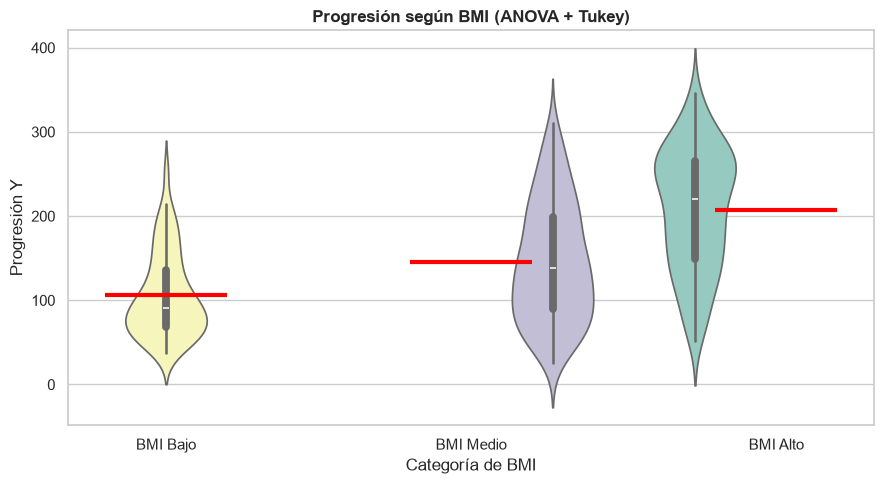

In [14]:
tukey = pairwise_tukeyhsd(df["Y"], df["BMI_cat"])
print(tukey.summary())

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    x="BMI_cat", y="Y", data=df, hue="BMI_cat", palette="Set3", legend=False, inner="box", ax=ax
)
medias = df.groupby("BMI_cat", observed=True)["Y"].mean()
for i, mm in enumerate(medias):
    ax.hlines(mm, i - 0.2, i + 0.2, color="red", linewidth=3, zorder=5)
ax.set_title("Progresión según BMI (ANOVA + Tukey)", fontweight="bold")
ax.set_xlabel("Categoría de BMI")
ax.set_ylabel("Progresión Y")
plt.tight_layout()
plt.show()


El resultado es robusto. ANOVA con p minúsculo, Kruskal-Wallis lo confirma sin asumir normalidad, y el eta cuadrado de 0.303 indica que el BMI explica cerca del 30% de la variación en la progresión. Tukey muestra que los tres grupos difieren entre sí, a mayor BMI mayor progresión, de forma escalonada. Como Levene detecta varianzas distintas, la prueba no paramétrica resultó un respaldo necesario.


## 7. Análisis multivariado y auditoría de la limpieza

Hasta aquí cada factor se analizó por separado. Pero la pregunta del objetivo, qué explica la progresión, se responde mejor mirando todos los predictores a la vez. Esta sección suma un ranking de predictores y una regresión múltiple, y de paso usa esos resultados para auditar las decisiones que se tomaron en la limpieza del dataset.


### Ranking de predictores frente a `Y`

Se ordenan todos los predictores por su asociación con la progresión, usando Pearson y Spearman. Spearman es relevante porque las variables no son normales, captura relaciones monótonas sin asumir linealidad.


In [15]:
pred = ["AGE", "BMI", "BP", "S1", "S3", "S5", "S6"]

filas = []
for v in pred:
    r, pr = stats.pearsonr(df[v], df["Y"])
    rho, ps = stats.spearmanr(df[v], df["Y"])
    filas.append([v, r, pr, rho, ps])

ranking = pd.DataFrame(filas, columns=["Variable", "Pearson", "p_Pearson", "Spearman", "p_Spearman"])
ranking = ranking.reindex(ranking["Spearman"].abs().sort_values(ascending=False).index).reset_index(drop=True)
ranking.round(3)


,Variable,Pearson,p_Pearson,Spearman,p_Spearman
0,S5,0.566,0.0,0.589,0.0
1,BMI,0.586,0.0,0.561,0.0
2,BP,0.441,0.0,0.416,0.0
3,S3,-0.395,0.0,-0.410,0.0
4,S6,0.382,0.0,0.351,0.0
5,S1,0.212,0.0,0.232,0.0
6,AGE,0.188,0.0,0.198,0.0


El ranking corrige una idea incompleta. La progresión no depende solo del BMI. `S5`, el logaritmo de triglicéridos, correlaciona igual o un poco más que el BMI con la progresión. `BP` aparece tercero con fuerza. Quedarse solo con el BMI, como sugería el análisis univariado, dejaría afuera factores igual de determinantes.


### Regresión lineal múltiple

La regresión modela `Y` en función de todos los predictores a la vez. Permite ver qué factores siguen siendo significativos cuando se controla por los demás, y cuánta variación explica el conjunto. Los coeficientes estandarizados hacen comparables las magnitudes a pesar de las distintas escalas.


In [16]:
X = sm.add_constant(df[pred])
modelo = sm.OLS(df["Y"], X).fit()

# Coeficientes estandarizados para comparar pesos entre variables de distinta escala
z_pred = (df[pred] - df[pred].mean()) / df[pred].std()
z_y = (df["Y"] - df["Y"].mean()) / df["Y"].std()
modelo_z = sm.OLS(z_y, sm.add_constant(z_pred)).fit()

print(f"R² = {modelo.rsquared:.3f}   R² ajustado = {modelo.rsquared_adj:.3f}   F p-valor = {modelo.f_pvalue:.1e}")
print(f"\n{'Variable':6}{'coef':>10}{'beta_std':>11}{'p-valor':>10}  signif")
for v in pred:
    pval = modelo.pvalues[v]
    sig = "***" if pval<0.001 else "**" if pval<0.01 else "*" if pval<0.05 else "ns"
    print(f"{v:6}{modelo.params[v]:>10.2f}{modelo_z.params[v]:>11.3f}{pval:>10.3f}  {sig}")


R² = 0.498   R² ajustado = 0.490   F p-valor = 3.6e-61

Variable      coef   beta_std   p-valor  signif
AGE        -0.11     -0.019     0.616  ns
BMI         6.06      0.347     0.000  ***
BP          0.94      0.168     0.000  ***
S1         -0.22     -0.098     0.023  *
S3         -0.50     -0.085     0.039  *
S5         51.86      0.351     0.000  ***
S6          0.22      0.033     0.422  ns


El modelo explica el 49.8% de la variación en la progresión, un ajuste alto para datos clínicos. Tres factores dominan y son significativos al máximo nivel, `BMI` y `S5` casi empatados arriba, y `BP` detrás. En cambio `AGE` y `S6` dejan de ser significativos al controlar por el resto, su aparente relación se explicaba por otras variables. La conclusión madura es que la progresión está impulsada por un trío, masa corporal, triglicéridos y presión arterial, no por un único factor.


### Diagnóstico de influencia, una mirada crítica a los outliers

La limpieza conservó los valores atípicos por ser datos clínicos reales, una decisión correcta. Pero conservar no es lo mismo que ignorar. Con el modelo ajustado se puede medir cuáles pacientes influyen desproporcionadamente en los resultados mediante la distancia de Cook.


Umbral de Cook (4/n) = 0.0090
Pacientes influyentes = 21 de 442
Normalidad de residuos (Shapiro): p = 0.1475 -> modelo válido


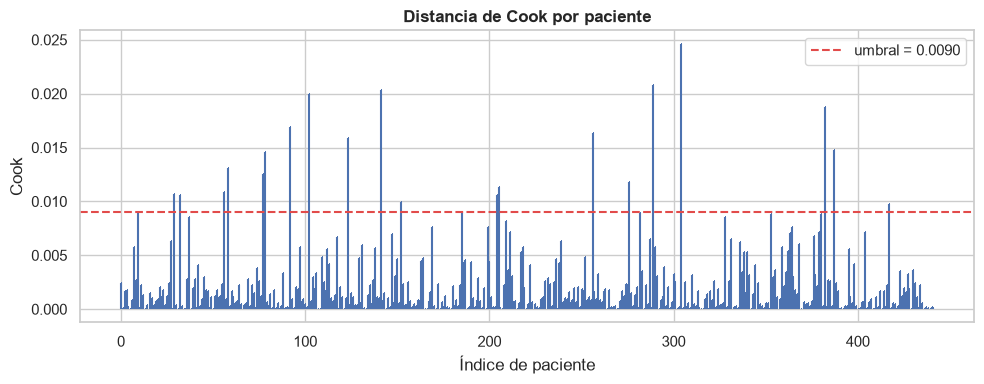

In [17]:
influencia = modelo.get_influence()
cooks = influencia.cooks_distance[0]
umbral = 4 / len(df)
n_influyentes = (cooks > umbral).sum()

print(f"Umbral de Cook (4/n) = {umbral:.4f}")
print(f"Pacientes influyentes = {n_influyentes} de {len(df)}")

# Validación del modelo: ¿los residuos son normales?
W, p_resid = stats.shapiro(modelo.resid)
print(f"Normalidad de residuos (Shapiro): p = {p_resid:.4f} -> {'modelo válido' if p_resid>0.05 else 'revisar'}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(cooks, markerfmt=",", basefmt=" ")
ax.axhline(umbral, color="#E24B4A", linestyle="--", label=f"umbral = {umbral:.4f}")
ax.set_title("Distancia de Cook por paciente", fontweight="bold")
ax.set_xlabel("Índice de paciente")
ax.set_ylabel("Cook")
ax.legend()
plt.tight_layout()
plt.show()


Hay 21 pacientes con influencia por encima del umbral, alrededor del 5%. Ninguno es extremo, el máximo está lejos del valor crítico de alarma. Esto confirma que conservar los outliers fue acertado, no distorsionan el modelo de forma grave. Como dato que valida todo el análisis, los residuos del modelo son normales, así que la regresión es estadísticamente válida pese a que las variables individuales no lo eran.


### Auditoría de las decisiones de limpieza

El análisis estadístico permite revisar si la limpieza eligió bien. Las decisiones se habían tomado mirando la correlación entre predictores, sin considerar la relación con el target. Al cruzarlas con `Y` se obtiene lo siguiente.

La eliminación de `S2` fue correcta. Se conservó `S1`, que correlaciona 0.21 con la progresión frente al 0.17 de `S2`. Se quedó con el mejor predictor del par.

La eliminación de `S4` es discutible. `S4`, el cociente colesterol total sobre HDL, correlacionaba 0.43 con la progresión, más que casi todas las variables conservadas. Se descartó por ser una variable derivada, pero un cociente puede resumir un riesgo mejor que sus componentes sueltos. Para inferencia pura tiene sentido quitarla porque introduce dependencia matemática exacta, pero se perdió un predictor fuerte. Es un tradeoff que conviene dejar explícito.

La lección general es que limpieza y análisis no son etapas separadas, se retroalimentan. El análisis valida o cuestiona las decisiones de la limpieza, y en un flujo maduro esos hallazgos vuelven a la etapa de depuración con criterios mejores.


## 8. Comparación visual, dataset sin limpiar y limpio

Se comparan las matrices de correlación de ambas versiones para mostrar el efecto de la depuración sobre la interpretabilidad.


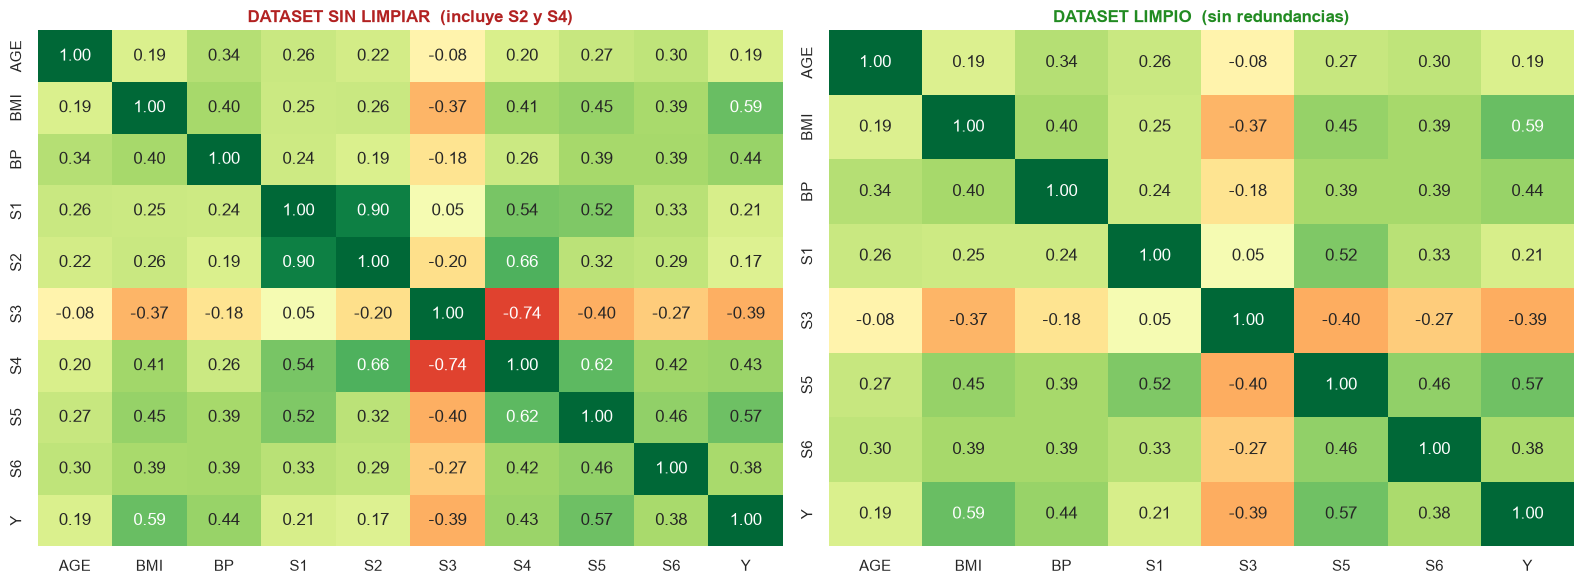

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    df_sin_limpiar[["AGE", "BMI", "BP", "S1", "S2", "S3", "S4", "S5", "S6", "Y"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title("DATASET SIN LIMPIAR  (incluye S2 y S4)", fontweight="bold", color="#B22222")

sns.heatmap(
    df[["AGE", "BMI", "BP", "S1", "S3", "S5", "S6", "Y"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=axes[1],
    cbar=False,
)
axes[1].set_title("DATASET LIMPIO  (sin redundancias)", fontweight="bold", color="#228B22")

plt.tight_layout()
plt.show()


En el dataset sin limpiar aparece la correlación de 0.90 entre `S1` y `S2`, y `S4` muestra dependencias fuertes con varias columnas por ser una variable derivada. En el limpio esas correlaciones espurias desaparecen y cada variable aporta información propia, lo que deja un mapa más fácil de leer.


## 9. Conclusiones

La progresión de la diabetes está impulsada por un conjunto de factores, no por uno solo. La regresión múltiple, que explica cerca del 50% de la variación, identifica un trío dominante, la masa corporal, los triglicéridos `S5` y la presión arterial. El BMI y `S5` pesan casi igual, un matiz que el análisis univariado centrado solo en BMI no mostraba. La edad y la glucosa `S6`, en cambio, no aportan una vez controlados los demás factores.

El sexo no es relevante. El T-Test, su respaldo no paramétrico y un tamaño de efecto despreciable coinciden en que no hay diferencia de progresión entre hombres y mujeres.

La verificación de supuestos fue decisiva en todo el recorrido. Las variables no son normales, así que las pruebas no paramétricas validaron los resultados paramétricos, y el diagnóstico de influencia confirmó que conservar los outliers no comprometió el modelo, cuyos residuos sí resultaron normales.

Por último, el análisis sirvió para auditar la limpieza. Confirmó que la elección de `S1` sobre `S2` fue correcta, pero mostró que descartar `S4` sacrificó un predictor fuerte. Limpieza y análisis se retroalimentan, y revisar uno a la luz del otro es lo que da solidez al trabajo.
